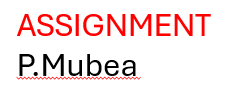

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

## Data Importation

In [11]:
gss = pd.read_csv("Germandata.csv")
gss

,S/no,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car
...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,NaN,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV


In [12]:
gss.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   S/no              1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [13]:
missing_values = gss.isnull().sum()
missing_values

S/no                  0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

In [14]:
gss.tail(10)

,S/no,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
990,990,37,male,1,own,NaN,NaN,3565,12,education
991,991,34,male,1,own,moderate,NaN,1569,15,radio/TV
992,992,23,male,1,rent,NaN,little,1936,18,radio/TV
993,993,30,male,3,own,little,little,3959,36,furniture/equipment
994,994,50,male,2,own,NaN,NaN,2390,12,car
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment
996,996,40,male,3,own,little,little,3857,30,car
997,997,38,male,2,own,little,NaN,804,12,radio/TV
998,998,23,male,2,free,little,little,1845,45,radio/TV
999,999,27,male,2,own,moderate,moderate,4576,45,car


In [18]:
gss_credit = gss[gss["Credit amount"] > 5000]
gss_credit

,S/no,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
5,5,35,male,1,free,NaN,NaN,9055,36,education
7,7,35,male,3,rent,little,moderate,6948,36,car
9,9,28,male,3,own,little,moderate,5234,30,car
...,...,...,...,...,...,...,...,...,...,...
973,973,36,male,2,rent,little,little,7297,60,business
980,980,49,male,2,own,little,moderate,8386,30,furniture/equipment
983,983,26,male,2,own,little,little,8229,36,car
986,986,33,male,2,own,little,rich,6289,42,business


In [24]:
gss_selected = gss.loc[:,["Age", "Sex", "Credit amount", "Duration"]]
gss_selected.head()

,Age,Sex,Credit amount,Duration
0,67,male,1169,6
1,22,female,5951,48
2,49,male,2096,12
3,45,male,7882,42
4,53,male,4870,24


In [25]:
gss_select = gss.loc[:, ["Job", "Saving accounts", "Purpose"]]
gss_select.head()

,Job,Saving accounts,Purpose
0,2,NaN,radio/TV
1,2,little,radio/TV
2,1,little,education
3,2,little,furniture/equipment
4,2,little,car


In [26]:
gss_mutated = gss.assign(duration_category = np.where(gss["Duration"] > 42, "High", "Low"))
gss_mutated

,S/no,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,duration_category
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,Low
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,High
2,2,49,male,1,own,little,NaN,2096,12,education,Low
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,Low
4,4,53,male,2,free,little,little,4870,24,car,Low
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,Low
996,996,40,male,3,own,little,little,3857,30,car,Low
997,997,38,male,2,own,little,NaN,804,12,radio/TV,Low
998,998,23,male,2,free,little,little,1845,45,radio/TV,High


In [27]:
gss_mutate = gss.assign(age_group = np.where(gss["Age"] > 40, "Adults", "Youths"))
gss_mutate

,S/no,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,age_group
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,Adults
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,Youths
2,2,49,male,1,own,little,NaN,2096,12,education,Adults
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,Adults
4,4,53,male,2,free,little,little,4870,24,car,Adults
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,Youths
996,996,40,male,3,own,little,little,3857,30,car,Youths
997,997,38,male,2,own,little,NaN,804,12,radio/TV,Youths
998,998,23,male,2,free,little,little,1845,45,radio/TV,Youths


In [32]:
gss_summarized = gss.groupby("Sex")["Age"].agg(['mean', 'count'])
gss_summarized

,mean,count
Sex,,
female,32.803226,310
male,36.778261,690


In [31]:
gss_summarize = gss.groupby("Job")["Credit amount"].agg(['mean', 'count'])
gss_summarize

,mean,count
Job,,
0,2745.136364,22
1,2358.520000,200
2,3070.965079,630
3,5435.493243,148


In [35]:
gss_summarize = gss.groupby("Job")["Credit amount"].mean().reset_index().sort_values(by="Credit amount", ascending=False)
gss_summarize

,Job,Credit amount
3,3,5435.493243
2,2,3070.965079
0,0,2745.136364
1,1,2358.520000


In [36]:
gss_processed = (
    gss.query("Age > 40")
    .loc[:, ["Job", "Housing", "Credit amount"]]
    .assign(income_category=lambda x: np.where(x["Credit amount"] > 5000, "High", "Low"))
    .sort_values(by="Credit amount", ascending=False))
gss_processed

,Job,Housing,Credit amount,income_category
95,2,rent,15945,High
818,3,own,15857,High
917,3,own,14896,High
374,3,free,14782,High
378,3,free,14318,High
...,...,...,...,...
590,1,own,385,Low
379,1,own,362,Low
157,1,own,339,Low
177,2,own,338,Low
